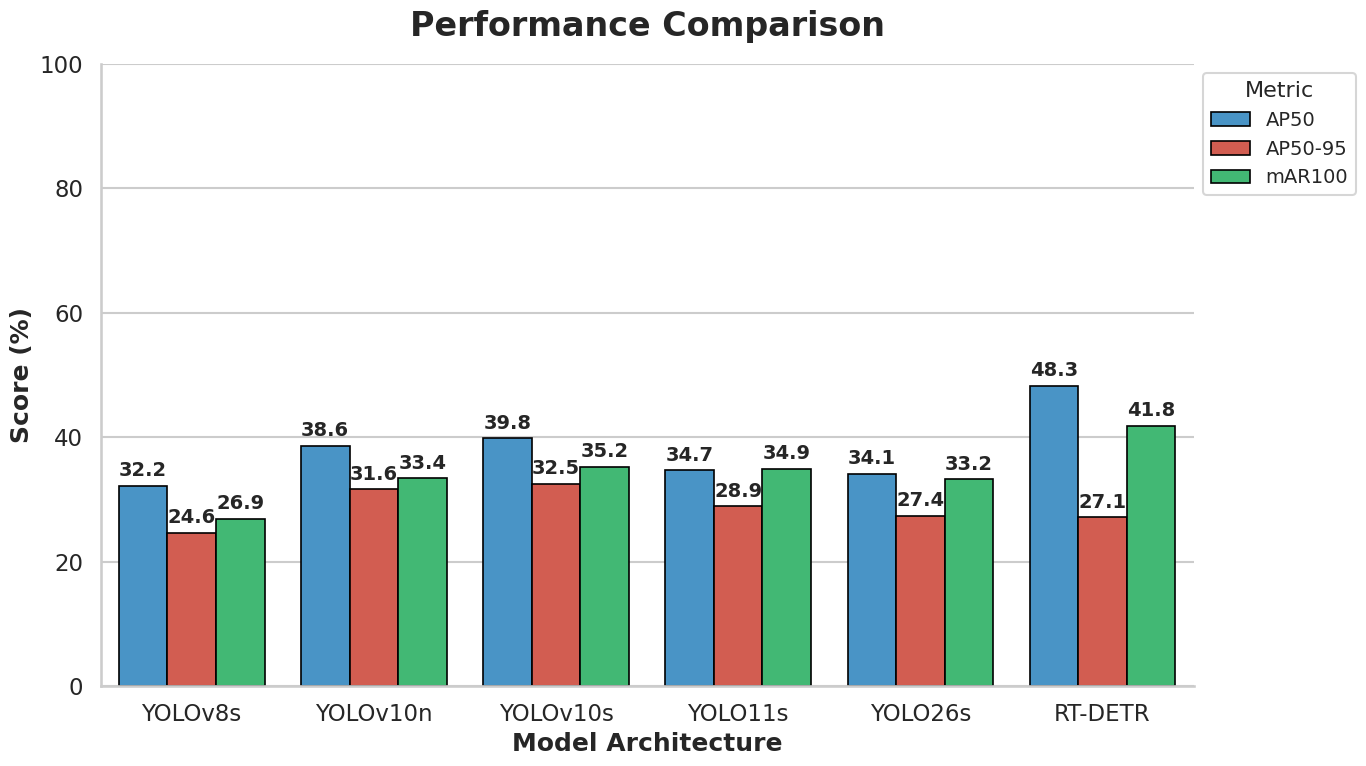

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import json

# --- 1. DATA CONFIGURATION (JSON Format) ---
# Replace this string with your actual data
json_data = """
[
    {
        "Model": "YOLOv8s",
        "AP50": 32.2,
        "AP50-95": 24.6,
        "mAR100": 26.9
    },
    {
        "Model": "YOLOv10n",
        "AP50": 38.6,
        "AP50-95": 31.6,
        "mAR100": 33.4
    },
    {
        "Model": "YOLOv10s",
        "AP50": 39.8,
        "AP50-95": 32.5,
        "mAR100": 35.2
    },
    {
        "Model": "YOLO11s",
        "AP50-95": 28.9,
        "AP50": 34.7,
        "mAR100": 34.9
    },
    {
        "Model": "YOLO26s",
        "AP50-95": 27.4,
        "AP50": 34.1,
        "mAR100": 33.2
    },
    {
        "Model": "RT-DETR",
        "AP50": 48.3,
        "AP50-95": 27.1,
        "mAR100": 41.8
    }
]
"""

# Convert JSON to DataFrame
data = json.loads(json_data)
df = pd.DataFrame(data)

# Transform data for Seaborn (melt to long format for easier grouping)
# This turns the columns mAP50, mAP50-95, etc., into rows under a "Metric" column
df_melted = df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# --- 2. PLOTTING STYLE ---
# "talk" context scales everything up for presentations/posters
sns.set_context("talk") 
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(14, 8))

# Define a custom color palette (Blue, Red, Green - distinct & professional)
custom_palette = ["#3498db", "#e74c3c", "#2ecc71"]

# Create Bar Plot
ax = sns.barplot(
    data=df_melted,
    x="Model",
    y="Score",
    hue="Metric",
    palette=custom_palette,
    edgecolor="black", # Adds a border to bars for definition
    linewidth=1.2
)

# --- 3. AESTHETICS & ANNOTATIONS ---
# Add values on top of bars
for container in ax.containers:
    # fmt='%.1f' formats to 1 decimal place
    ax.bar_label(container, fmt='%.1f', padding=4, fontsize=14, fontweight='bold')

# Customize axes and titles
plt.title("Performance Comparison", fontsize=24, fontweight='bold', pad=20)
plt.ylabel("Score (%)", fontsize=18, fontweight='bold')
plt.xlabel("Model Architecture", fontsize=18, fontweight='bold')
plt.ylim(0, 100)  # Fix Y-axis to 0-100 since it is percentage

# Clean up the legend (move outside to avoid blocking data)
plt.legend(title="Metric", title_fontsize='16', fontsize='14', loc='upper left', bbox_to_anchor=(1, 1))

# Remove top and right spines for a cleaner look
sns.despine()

# Adjust layout to prevent clipping of the legend
plt.tight_layout()

# Save high-quality image
plt.savefig('model_comparison.png', dpi=300)
plt.show()